In [57]:
import pyMMF
import numpy as np
import matplotlib.pyplot as plt

In [83]:
NA = 0.275
radius = 3 # in microns
areaSize = 2.5*radius # calculate the field on an area larger than the diameter of the fiber
npoints = 2**7 # resolution of the window
n1 = 1.45
wl = 0.6328 # wavelength in microns
curvature = None

In [84]:
profile = pyMMF.IndexProfile(npoints = npoints, areaSize = areaSize)

In [85]:
profile.initParabolicGRIN(n1=n1, a=radius, NA=NA)

In [86]:
solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)

2023-12-06 16:00:54,925 - pyMMF.core [DEBUG  ]  Debug mode ON.


In [87]:
NmodesMax = pyMMF.estimateNumModesGRIN(wl,radius,NA)

In [88]:
modes = solver.solve(nmodesMax=NmodesMax+10,
boundary = 'close',
mode = 'eig',
curvature = curvature)

2023-12-06 16:00:55,902 - pyMMF.solv [INFO   ]  Solving the spatial eigenvalue problem for mode finding.
2023-12-06 16:00:55,903 - pyMMF.solv [INFO   ]  Use close boundary condition.
2023-12-06 16:01:00,009 - pyMMF.solv [INFO   ]  Solver found 10 modes is 4.11 seconds.
2023-12-06 16:01:00,010 - pyMMF.core [DEBUG  ]  Mode data stored in memory.


In [89]:
modes = solver.solve(mode = 'radial')

2023-12-06 16:01:00,035 - pyMMF.solv [INFO   ]  Found 2 radial mode(s) for m=0
2023-12-06 16:01:00,036 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-12-06 16:01:00,038 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 2
2023-12-06 16:01:00,050 - pyMMF.solv [INFO   ]  Found 2 radial mode(s) for m=1
2023-12-06 16:01:00,052 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-12-06 16:01:00,056 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 2
2023-12-06 16:01:00,068 - pyMMF.solv [INFO   ]  Found 1 radial mode(s) for m=2
2023-12-06 16:01:00,069 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-12-06 16:01:00,080 - pyMMF.solv [INFO   ]  Found 1 radial mode(s) for m=3
2023-12-06 16:01:00,080 - pyMMF.solv [INFO   ]  Searching propagation constant for |l| = 1
2023-12-06 16:01:00,092 - pyMMF.solv [INFO   ]  Found 0 radial mode(s) for m=4
2023-12-06 16:01:00,093 - pyMMF.solv [INFO   ]  Solver foun

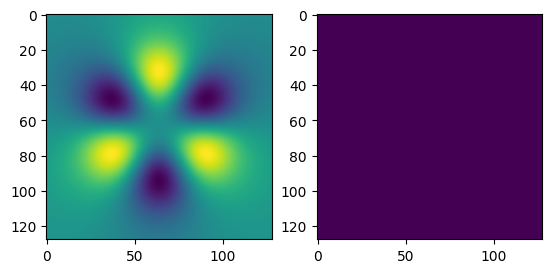

In [153]:
m = 9
plt.figure()
plt.subplot(121)
plt.imshow(np.real(modes.profiles[m]).reshape([npoints]*2))
plt.subplot(122)
plt.imshow(np.imag(modes.profiles[m]).reshape([npoints]*2))

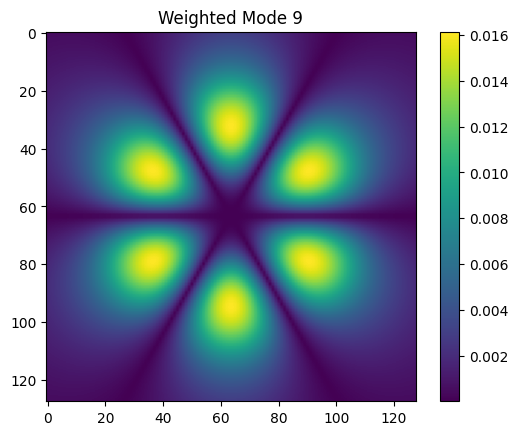

In [163]:
a = 0.8  # adjust the value of 'a' based on your requirements
phi = np.pi / 6  # adjust the value of 'phi' based on your requirements

# Create complex weights
mode_weights = a * np.exp(1j * phi)

# Visualize a specific mode (e.g., mode 0) with weights
m = 9
plt.figure()

# Apply complex weights to the magnitude of the mode profile
weighted_magnitude_profile = np.abs(mode_weights * modes.profiles[m])
weighted_module_profile = np.angle(mode_weights * modes.profiles[m])

plt.imshow(weighted_magnitude_profile.reshape([npoints] * 2), cmap='viridis')
plt.colorbar()
plt.title(f'Weighted Mode {m}')

plt.show()

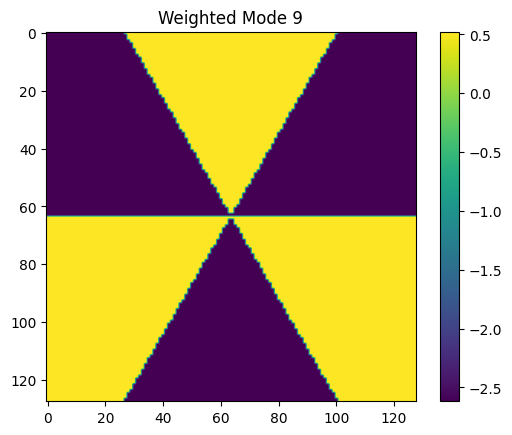

In [165]:
weighted_magnitude_profile = np.angle(mode_weights * modes.profiles[m])

plt.imshow(weighted_magnitude_profile.reshape([npoints] * 2), cmap='viridis')
plt.colorbar()
plt.title(f'Weighted Mode {m}')

plt.show()

In [154]:


# Define complex weights for 10 modes
a1, phi1 = 0.5, np.pi/4  
a2, phi2 = 0.3, np.pi/3  
a3, phi3 = 0.7, np.pi/2  
a4, phi4 = 0.2, np.pi/6  
a5, phi5 = 0.6, np.pi/8  
a6, phi6 = 0.4, np.pi/2  
a7, phi7 = 0.8, np.pi/4  
a8, phi8 = 0.1, np.pi/3  
a9, phi9 = 0.9, np.pi/6  
a10, phi10 = 0.3, np.pi/8  

weights = np.array([
    a1 * np.exp(1j * phi1),
    a2 * np.exp(1j * phi2),
    a3 * np.exp(1j * phi3),
    a4 * np.exp(1j * phi4),
    a5 * np.exp(1j * phi5),
    a6 * np.exp(1j * phi6),
    a7 * np.exp(1j * phi7),
    a8 * np.exp(1j * phi8),
    a9 * np.exp(1j * phi9),
    a10 * np.exp(1j * phi10),
])

# Example multiplication for 10 modes (replace with your actual mode profiles)
mode_profiles = [np.random.random((npoints, npoints)) + 1j * np.random.random((npoints, npoints)) for _ in range(10)]

# Multiply each mode profile with its corresponding weight
superposed_modes = [weights[i] * mode_profiles[i] for i in range(10)]

# Sum up the superposed modes
superposition = np.sum(superposed_modes, axis=0)


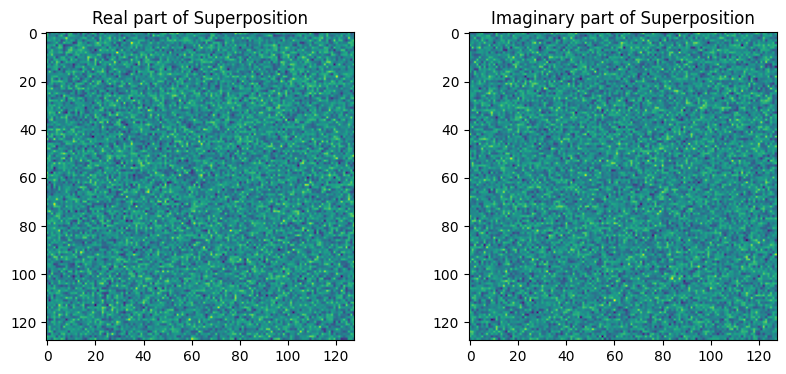

In [155]:
import matplotlib.pyplot as plt

# Visualize the real part of the superposition
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.imshow(np.real(superposition), cmap='viridis')
plt.title('Real part of Superposition')

# Visualize the imaginary part of the superposition
plt.subplot(122)
plt.imshow(np.imag(superposition), cmap='viridis')
plt.title('Imaginary part of Superposition')

plt.show()


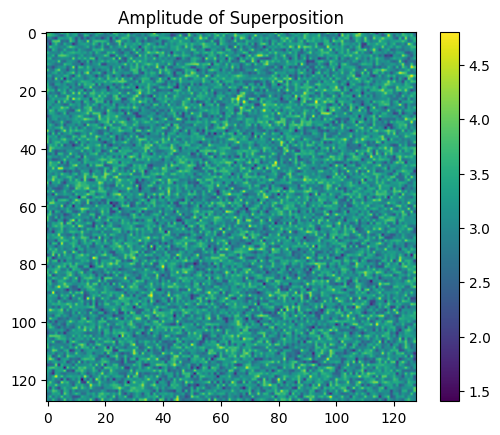

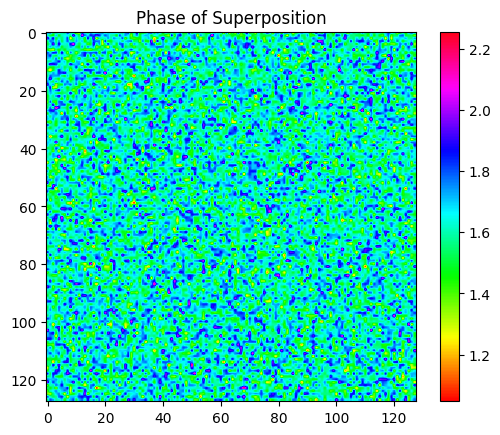

In [169]:
import numpy as np

# Define complex weights for 10 modes
weights = np.array([
    a1 * np.exp(1j * phi1),
    a2 * np.exp(1j * phi2),
    a3 * np.exp(1j * phi3),
    a4 * np.exp(1j * phi4),
    a5 * np.exp(1j * phi5),
    a6 * np.exp(1j * phi6),
    a7 * np.exp(1j * phi7),
    a8 * np.exp(1j * phi8),
    a9 * np.exp(1j * phi9),
    a10 * np.exp(1j * phi10),
])

# Example multiplication for 10 modes (replace with your actual mode profiles)
mode_profiles = [np.random.random((npoints, npoints)) + 1j * np.random.random((npoints, npoints)) for _ in range(10)]

# Calculate the superposition
superposition = np.sum(weights[:, np.newaxis, np.newaxis] * mode_profiles, axis=0)


a1, phi1 = 0.5, np.pi/4  
a2, phi2 = 0.3, np.pi/3  
a3, phi3 = 0.7, np.pi/2  
a4, phi4 = 0.2, np.pi/6  
a5, phi5 = 0.6, np.pi/8  
a6, phi6 = 0.4, np.pi/2  
a7, phi7 = 0.8, np.pi/4  
a8, phi8 = 0.1, np.pi/3  
a9, phi9 = 0.9, np.pi/6  
a10, phi10 = 0.3, np.pi/8                       

# Assuming 'superposition' is already calculated as described in the previous response

# Calculate amplitude
amplitude = np.abs(superposition)

# Plot amplitude
plt.imshow(amplitude, cmap='viridis')
plt.title('Amplitude of Superposition')
plt.colorbar()
plt.show()


# Assuming 'superposition' is already calculated as described in the previous response

# Calculate phase
phase = np.angle(superposition)

# Plot phase
plt.imshow(phase, cmap='hsv')  # 'hsv' colormap represents phase well
plt.title('Phase of Superposition')
plt.colorbar()
plt.show()



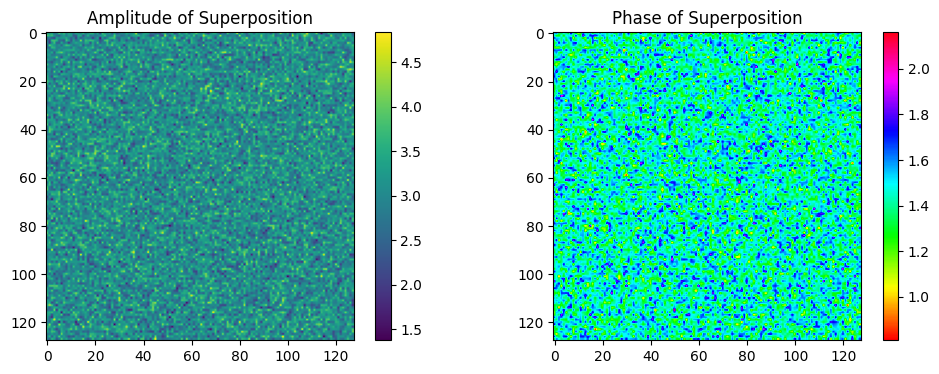

In [170]:

# Assuming 'mode_profiles' and 'weights' are already defined

# Set specific weights
weights[0] = 0.5  # New weight for mode 1
weights[1] = 0.5  # New weight for mode 2
# Keep other weights unchanged

# Calculate superposition
superposition = np.sum(weights[:, np.newaxis, np.newaxis] * mode_profiles, axis=0)

# Calculate amplitude and phase
amplitude = np.abs(superposition)
phase = np.angle(superposition)

# Plot amplitude
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(amplitude, cmap='viridis')
plt.title('Amplitude of Superposition')
plt.colorbar()

# Plot phase
plt.subplot(1, 2, 2)
plt.imshow(phase, cmap='hsv')
plt.title('Phase of Superposition')
plt.colorbar()

plt.show()


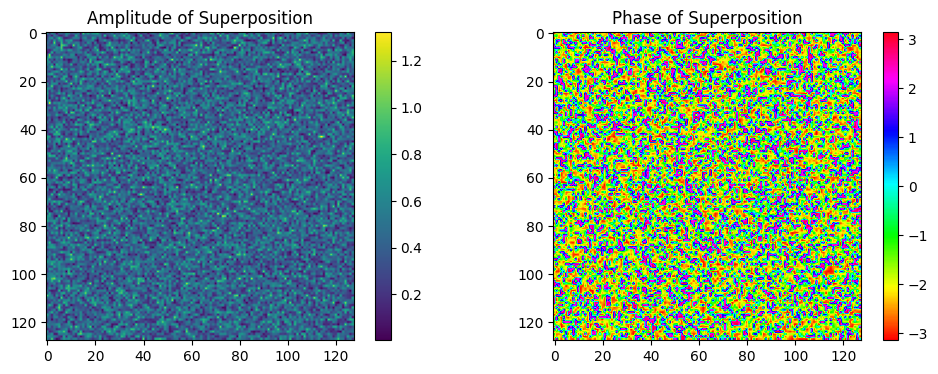

In [171]:

# Assuming 'mode_profiles' is already defined

# Number of modes
num_modes = len(mode_profiles)

# Generate random complex weights
rand_a = np.random.rand(num_modes)
rand_phi = 2 * np.pi * np.random.rand(num_modes)
rand_weights = rand_a * np.exp(1j * rand_phi)

# Normalize weights to have a total magnitude of 1
rand_weights /= np.linalg.norm(rand_weights)

# Calculate superposition
superposition = np.sum(rand_weights[:, np.newaxis, np.newaxis] * mode_profiles, axis=0)

# Calculate amplitude and phase
amplitude = np.abs(superposition)
phase = np.angle(superposition)

# Plot amplitude
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(amplitude, cmap='viridis')
plt.title('Amplitude of Superposition')
plt.colorbar()

# Plot phase
plt.subplot(1, 2, 2)
plt.imshow(phase, cmap='hsv')
plt.title('Phase of Superposition')
plt.colorbar()

plt.show()